# TP1 - Pipeline básico para construcción de modelos PINN

In [49]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy import linalg
from scipy.interpolate import griddata
import seaborn as sns
import pandas as pd

torch.manual_seed(0)
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda



## Datasets de puntos de colocación

In [50]:
# Por enunciado
# Puntos de colocación y de datos
N_PDE = 1000
N_BC = 100
N_DATA = 10
# Límites
X_LIM = (0, 1)
Y_LIM = (0, 1)

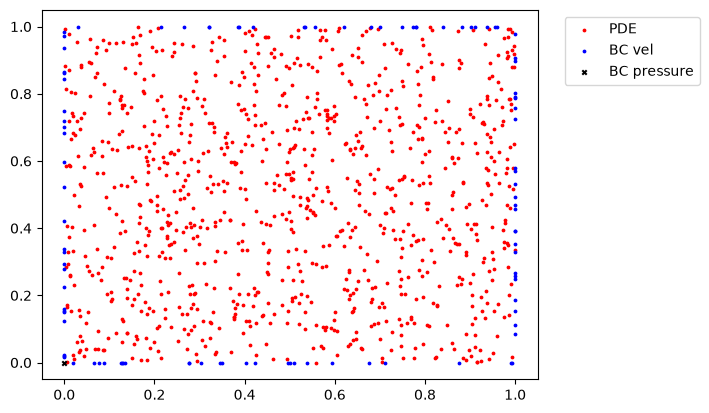

In [51]:
# Dataset en puntos de colocación
X_pde = torch.rand(N_PDE, 2)
plt.scatter(X_pde[:, 0], X_pde[:, 1], s=3, color='red', label='PDE')

# Dataset en puntos de condición de borde
X_bc_1 = torch.hstack((torch.rand(N_BC//4, 1), torch.zeros(N_BC//4, 1)))    # Borde inferior (y=0)
X_bc_2 = torch.hstack((torch.rand(N_BC//4, 1), torch.ones(N_BC//4, 1)))     # Borde superior (y=1)
X_bc_3 = torch.hstack((torch.zeros(N_BC//4, 1), torch.rand(N_BC//4, 1)))    # Borde izquierdo (x=0)
X_bc_4 = torch.hstack((torch.ones(N_BC//4, 1), torch.rand(N_BC//4, 1)))     # Borde derecho (x=1)
X_bc = torch.vstack((X_bc_1, X_bc_2, X_bc_3, X_bc_4))

y_vel_bc_1 = torch.zeros(N_BC//4, 2)                                        # Velocidad nula
y_vel_bc_2 = torch.hstack((torch.ones(N_BC//4, 1), torch.zeros(N_BC//4, 1)))# Velocidad unitaria en x
y_vel_bc_3 = torch.zeros(N_BC//4, 2)                                        # Velocidad nula
y_vel_bc_4 = torch.zeros(N_BC//4, 2)                                        # Velocidad nula
y_vel_bc = torch.vstack((y_vel_bc_1, y_vel_bc_2, y_vel_bc_3, y_vel_bc_4))

X_bc_p = torch.zeros(1,2)
y_bc_p = torch.zeros(1,1)

plt.scatter(X_bc[:, 0], X_bc[:, 1], s=3, color='blue', label='BC vel')
plt.scatter(X_bc_p[:, 0], X_bc_p[:, 1], s=10, color='black', marker='x', label='BC pressure')

plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

          x    y         p    u    v
10100  0.00  1.0 -4.632520  1.0  0.0
10101  0.01  1.0 -0.889585  1.0  0.0
10102  0.02  1.0 -0.443777  1.0  0.0
10103  0.03  1.0 -0.253398  1.0  0.0
10104  0.04  1.0 -0.172256  1.0  0.0


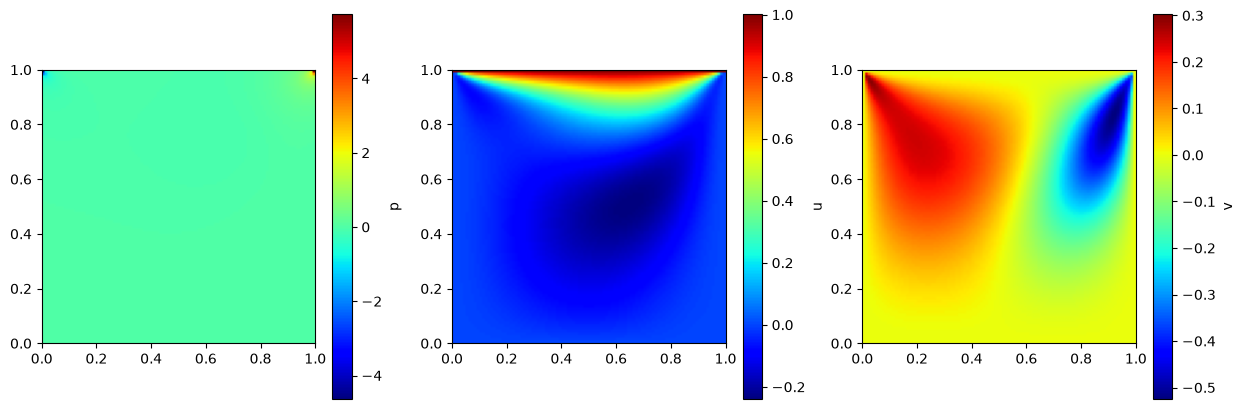

In [52]:
# Veamos como es la estructura de los datos suministrados
pressure_data = loadmat('../data/pressure.mat')
velocity_data = loadmat('../data/velocity.mat')

# print(pressure_data.keys())
# print(pressure_data['x'].shape)
# print(pressure_data['x'].transpose()[:10])
# print(velocity_data.keys())
# print(velocity_data['x'].shape)
# print(velocity_data['x'].transpose()[:10])

X_data_all = torch.tensor(np.hstack((pressure_data['x'].transpose(), pressure_data['y'].transpose())), dtype=torch.float32)
y_data_all = torch.tensor(np.hstack((pressure_data['p'].transpose(), velocity_data['u'].transpose(),velocity_data['v'].transpose())), dtype=torch.float32)


pred_df = pd.DataFrame({
    'x': X_data_all[:, 0].numpy(),
    'y': X_data_all[:, 1].numpy(),
    'p': y_data_all[:, 0].numpy(),
    'u': y_data_all[:, 1].numpy(),
    'v': y_data_all[:, 2].numpy(),
})

print(pred_df[pred_df['y']>= 1].head())

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
[ax.set_xlim(0,1) for ax in axs]
[ax.set_ylim(0,1) for ax in axs]
[
    ax.imshow(
        griddata(
            # np.column_stack((pred_df['x'], pred_df['y'])),
            X_data_all.numpy(),
            pred_df[col],
            np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100)),
            method='cubic'
        ),
        # pred_df.pivot_table(index='y', columns='x', values=col).values,
        origin='lower',
        extent=(0, 1, 0, 1),
        cmap='jet'
    )
    for ax, col in zip(axs, ['p', 'u', 'v'])
]
fig.colorbar(axs[0].images[0], ax=axs[0], label='p')
fig.colorbar(axs[1].images[0], ax=axs[1], label='u')
fig.colorbar(axs[2].images[0], ax=axs[2], label='v')


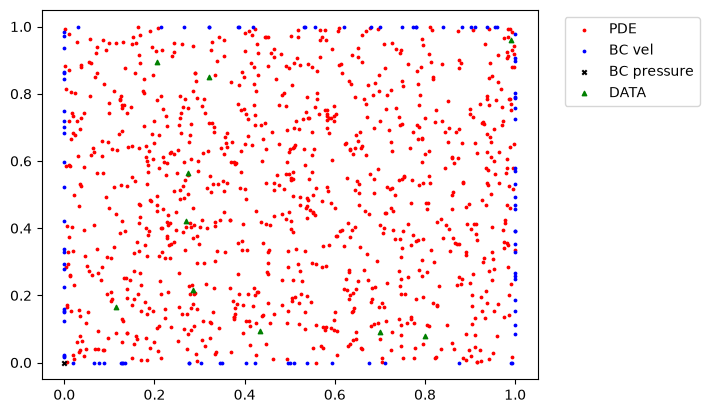

In [53]:
plt.scatter(X_pde[:, 0], X_pde[:, 1], s=3, color='red', label='PDE')
plt.scatter(X_bc[:, 0], X_bc[:, 1], s=3, color='blue', label='BC vel')
plt.scatter(X_bc_p[:, 0], X_bc_p[:, 1], s=10, color='black', marker='x', label='BC pressure')

idxs_data = torch.randint(0, X_data_all.shape[0], (N_DATA,))
X_data = X_data_all[idxs_data, :]
y_data = y_data_all[idxs_data, :]
plt.scatter(X_data[:, 0], X_data[:, 1], s=10, marker='^', color='green', label='DATA')

plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

## Implementación esquema vanilla PINN

In [54]:
class PINN(torch.nn.Module):
    def __init__(self, model_params):
        super(PINN, self).__init__()
        self.hidden_layers = model_params['hidden_layers']
        self.hidden_units = model_params['hidden_units']
        self.activation = model_params['activation']
        self.Re = model_params['Re']
        self.device = model_params['device']

        self.layers = torch.nn.ModuleList(
            [torch.nn.Linear(2, self.hidden_units)] +
            [torch.nn.Linear(self.hidden_units, self.hidden_units) for _ in range(self.hidden_layers - 1)] +
            [torch.nn.Linear(self.hidden_units, 3)]
        )

        self.apply(self.init_weights)

    def init_weights(self, m):
        if type(m) == torch.nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
            g = torch.nn.init.calculate_gain('tanh')
            torch.nn.init.xavier_uniform_(m.weight, gain=g)
            m.bias.data.fill_(0)

    def forward(self, x):
        y = x
        for layer in self.layers[:-1]:
            y = self.activation(layer(y))
        y = self.layers[-1](y)
        return y

    def momentum_conservation(self, x, y):
        p = y[:, 0]
        u = y[:, 1]
        v = y[:, 2]

        p_grad = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), create_graph=True)[0]
        p_x, p_y = p_grad[:, 0], p_grad[:, 1]
        u_grad = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_x, u_y = u_grad[:, 0], u_grad[:, 1]
        v_grad = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0]
        v_x, v_y = v_grad[:, 0], v_grad[:, 1]
        u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 0]
        u_yy = torch.autograd.grad(u_y, x, grad_outputs=torch.ones_like(u_y), create_graph=True)[0][:, 1]
        v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x), create_graph=True)[0][:, 0]
        v_yy = torch.autograd.grad(v_y, x, grad_outputs=torch.ones_like(v_y), create_graph=True)[0][:, 1]

        # momentum equations (Navier-Stokes) for incompressible flow
        residue_x = u * u_x + v * u_y + p_x - (1/self.Re) * (u_xx + u_yy)
        residue_y = u * v_x + v * v_y + p_y - (1/self.Re) * (v_xx + v_yy)
        return residue_x, residue_y 

    def continuity_equation(self, x, y):
        u = y[:, 1]
        v = y[:, 2]

        u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0][:, 0]
        v_y = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0][:, 1]

        return u_x + v_y


In [55]:
USE_DATA = False
# USE_DATA = True
EPOCHS = 40000
HIDDEN_LAYERS = 4
HIDDEN_UNITS = 64
ACTIVATION = torch.nn.Tanh()


In [56]:
model_params = {
    'hidden_layers': HIDDEN_LAYERS,
    'hidden_units': HIDDEN_UNITS,
    'activation': ACTIVATION,
    'Re': 100,
    'device': device
}

tags = ['PDE', 'BC_VEL', 'BC_P', 'DATA']
dataset = [
    torch.utils.data.TensorDataset(X_pde, torch.zeros(N_PDE, 1)),   # PDE
    torch.utils.data.TensorDataset(X_bc, y_vel_bc),                 # BC velocity
    torch.utils.data.TensorDataset(X_bc_p, y_bc_p),                 # BC pressure
    torch.utils.data.TensorDataset(X_data, y_data)                 # DATA
]

pinn = PINN(model_params).to(device)


In [57]:
loss = torch.nn.MSELoss()
opt = torch.optim.Adam(pinn.parameters(), lr=1e-3)
# opt = torch.optim.LBFGS(
#     pinn.parameters(), max_iter = 20,
#     lr=1e-3, 
#     tolerance_grad=1e-09, tolerance_change=1e-11, 
#     history_size=50, line_search_fn="strong_wolfe"
# )
epoch = 0


loss_history = []
pde_loss_history = []
bc_vel_loss_history = []
bc_p_loss_history = []
data_loss_history = []
l2_error = []
y_pred_hist = []
# for epoch in range(EPOCHS):
while epoch < EPOCHS:
    losses = {}
    opt.zero_grad()
    epoch_loss = []
    for tag in tags:
        if tag == 'PDE':
            X, y = dataset[0][:]
            X, y = X.to(device), y.to(device)
            X.requires_grad = True
            pred_y = pinn(X)
            residue_x, residue_y = pinn.momentum_conservation(X, pred_y)
            continuity = pinn.continuity_equation(X, pred_y)
            loss_pde = loss(residue_x, torch.zeros_like(residue_x)) + loss(residue_y, torch.zeros_like(residue_y)) + loss(continuity, torch.zeros_like(continuity))
            pde_loss_history.append(loss_pde.item())
            epoch_loss.append(loss_pde)
            losses['PDE'] = loss_pde.item()
        elif tag == 'BC_VEL':
            X, y_vel = dataset[1][:]
            X, y_vel = X.to(device), y_vel.to(device)
            X.requires_grad = True
            y_pred = pinn(X)[:, 1:3]
            loss_bc = loss(y_pred, y_vel)
            bc_vel_loss_history.append(loss_bc.item())
            epoch_loss.append(100 * loss_bc)
            losses['BC_VEL'] = loss_bc.item()
        elif tag == 'BC_P':
            X, y_p = dataset[2][:]
            X, y_p = X.to(device), y_p.to(device)
            X.requires_grad = True
            y_pred = pinn(X)[:, 0:1]
            loss_bc_p = loss(y_pred, y_p)
            bc_p_loss_history.append(loss_bc_p.item())
            epoch_loss.append(100 * loss_bc_p)
            losses['BC_P'] = loss_bc_p.item()
        elif tag == 'DATA' and USE_DATA:
            X, y_data = dataset[3][:]
            X, y_data = X.to(device), y_data.to(device)
            y_pred = pinn(X)
            loss_data = loss(y_pred, y_data)
            data_loss_history.append(loss_data.item())
            epoch_loss.append(loss_data)
            losses['DATA'] = loss_data.item()

    epoch_loss = sum(epoch_loss)
    epoch_loss.backward()

    opt.step()

    # Calculo la norma-2 del error
    pinn.eval()
    with torch.no_grad():
        y_pred = pinn(torch.tensor(X_data_all, dtype=torch.float64).to(device)).detach().cpu().numpy()
        l2_error.append(linalg.norm(y_data_all.numpy() - y_pred))

    if epoch % 10 == 0:
        print(f'Epoch {epoch}, PDE Loss: {losses["PDE"]:.6f}, BC vel. Loss: {losses["BC_VEL"]:.6f}, BC pres. Loss: {losses["BC_P"]:.6f}, DATA Loss: {losses["DATA"] if USE_DATA else "N/A"}')

    # guardado de y_pred
    if epoch % 500 == 0:
        y_pred_hist.append((epoch, y_pred))

    epoch += 1



/tmp/ipykernel_221659/3288611436.py:71: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_pred = pinn(torch.tensor(X_data_all, dtype=torch.float64).to(device)).detach().cpu().numpy()


Epoch 0, PDE Loss: 5.751414, BC vel. Loss: 0.742028, BC pres. Loss: 0.000000, DATA Loss: N/A
Epoch 10, PDE Loss: 1.231033, BC vel. Loss: 0.130244, BC pres. Loss: 0.000991, DATA Loss: N/A
Epoch 20, PDE Loss: 0.405692, BC vel. Loss: 0.045345, BC pres. Loss: 0.000022, DATA Loss: N/A
Epoch 30, PDE Loss: 0.658081, BC vel. Loss: 0.034272, BC pres. Loss: 0.000036, DATA Loss: N/A
Epoch 40, PDE Loss: 0.630629, BC vel. Loss: 0.022870, BC pres. Loss: 0.000001, DATA Loss: N/A
Epoch 50, PDE Loss: 0.645452, BC vel. Loss: 0.018828, BC pres. Loss: 0.000002, DATA Loss: N/A
Epoch 60, PDE Loss: 0.532250, BC vel. Loss: 0.016833, BC pres. Loss: 0.000000, DATA Loss: N/A
Epoch 70, PDE Loss: 0.501789, BC vel. Loss: 0.015828, BC pres. Loss: 0.000001, DATA Loss: N/A
Epoch 80, PDE Loss: 0.460816, BC vel. Loss: 0.015197, BC pres. Loss: 0.000001, DATA Loss: N/A
Epoch 90, PDE Loss: 0.440632, BC vel. Loss: 0.014654, BC pres. Loss: 0.000000, DATA Loss: N/A
Epoch 100, PDE Loss: 0.418416, BC vel. Loss: 0.014328, BC pre

Text(0.5, 0.98, 'Optimizador Adam')

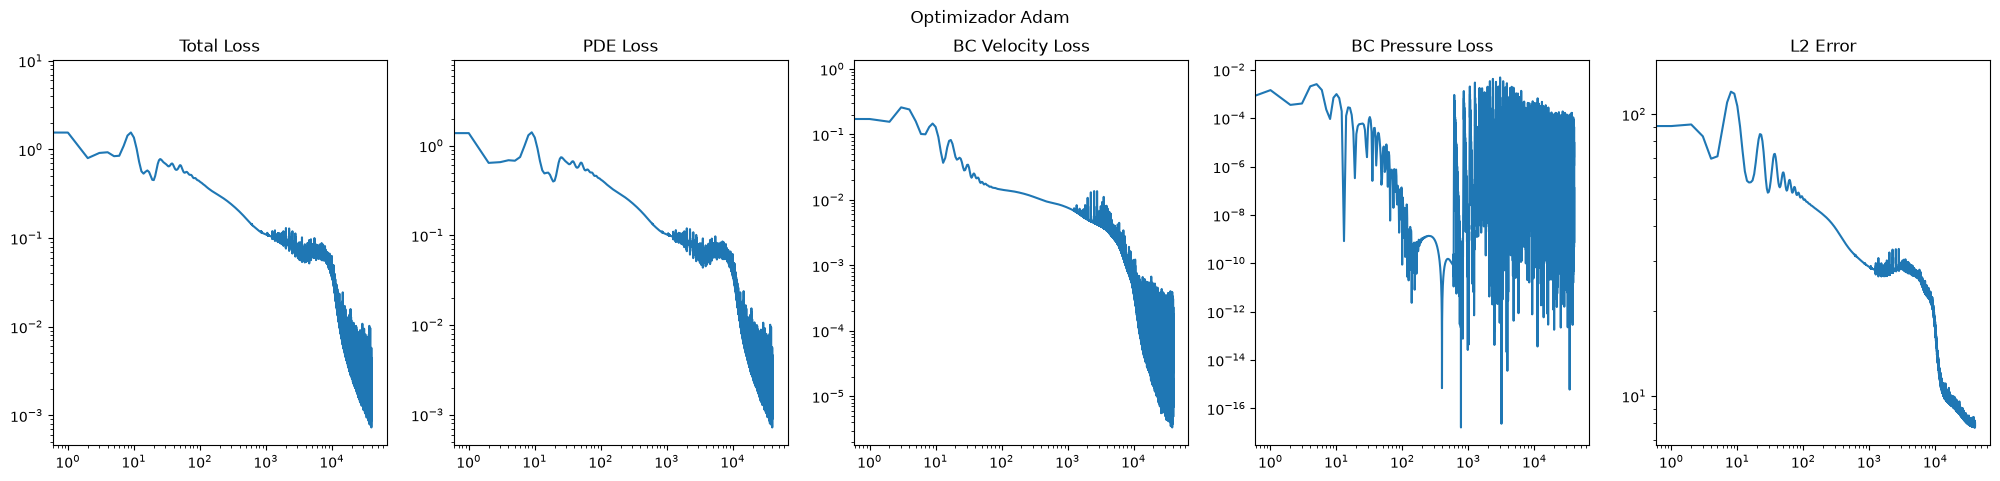

In [63]:
if USE_DATA:
    loss_history = [pde + bc_vel + bc_p + data for pde, bc_vel, bc_p, data in zip(pde_loss_history, bc_vel_loss_history, bc_p_loss_history, data_loss_history)]
else:
    loss_history = [pde + bc_vel + bc_p for pde, bc_vel, bc_p in zip(pde_loss_history, bc_vel_loss_history, bc_p_loss_history)]

# axs = 5 if USE_DATA else 4
axs = 6 if USE_DATA else 5
fig, axs = plt.subplots(1, axs, figsize=(5*axs, 5))
axs[0].plot(loss_history, label='Total Loss')
axs[0].set_title('Total Loss')
axs[1].plot(pde_loss_history, label='PDE Loss')
axs[1].set_title('PDE Loss')
axs[2].plot(bc_vel_loss_history, label='BC Velocity Loss')
axs[2].set_title('BC Velocity Loss')
axs[3].plot(bc_p_loss_history, label='BC Pressure Loss')
axs[3].set_title('BC Pressure Loss')
if USE_DATA:
    axs[4].plot(data_loss_history, label='DATA Loss')
    axs[4].set_title('DATA Loss')
axs[5 if USE_DATA else 4].plot(l2_error, label='L2 Error')
axs[5 if USE_DATA else 4].set_title('L2 Error')
[ax.set_yscale('log') for ax in axs]
[ax.set_xscale('log') for ax in axs]
fig.suptitle("Optimizador Adam")

/tmp/ipykernel_221659/2630775527.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_pred = pinn(torch.tensor(X_data_all, dtype=torch.float64).to(device)).detach().cpu().numpy()


Text(0.5, 0.98, 'Optimizador Adam')

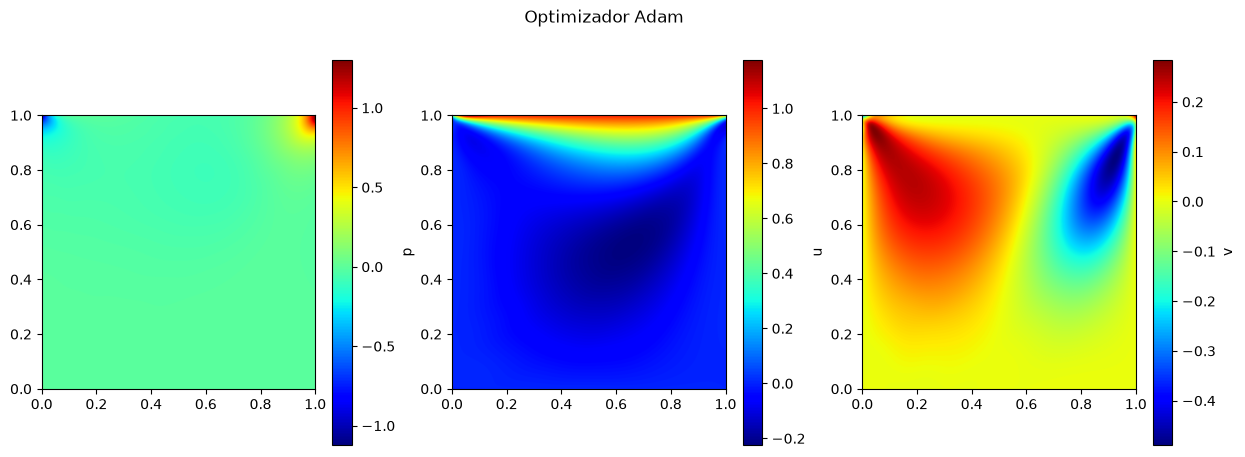

In [59]:
y_pred = pinn(torch.tensor(X_data_all, dtype=torch.float64).to(device)).detach().cpu().numpy()
pred_df = pd.DataFrame({
    'x': X_data_all[:, 0].numpy(),
    'y': X_data_all[:, 1].numpy(),
    'p': y_pred[:, 0],
    'u': y_pred[:, 1],
    'v': y_pred[:, 2],
})

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
[ax.set_xlim(0,1) for ax in axs]
[ax.set_ylim(0,1) for ax in axs]
[
    ax.imshow(
        griddata(
            # np.column_stack((pred_df['x'], pred_df['y'])),
            X_data_all.numpy(),
            pred_df[col],
            np.meshgrid(np.linspace(0, 1, 1000), np.linspace(0, 1, 1000)),
            method='cubic'
        ),
        # pred_df.pivot_table(index='y', columns='x', values=col).values,
        origin='lower',
        extent=(0, 1, 0, 1),
        cmap='jet'
    )
    for ax, col in zip(axs, ['p', 'u', 'v'])
]
fig.colorbar(axs[0].images[0], ax=axs[0], label='p')
fig.colorbar(axs[1].images[0], ax=axs[1], label='u')
fig.colorbar(axs[2].images[0], ax=axs[2], label='v')
fig.suptitle("Optimizador Adam")

In [60]:
error_l2 = linalg.norm(y_data_all.numpy() - y_pred)
print("Error L2:", error_l2)

Error L2: 7.845888756339256


      x    y     p_err     u_err     v_err
0  0.00  0.0  0.001173 -0.000569 -0.000414
1  0.01  0.0  0.001641 -0.000951 -0.001246
2  0.02  0.0  0.002007 -0.001217 -0.001764
3  0.03  0.0  0.002274 -0.001405 -0.002027
4  0.04  0.0  0.002476 -0.001537 -0.002089


Text(0.5, 0.98, 'Optimizador Adam')

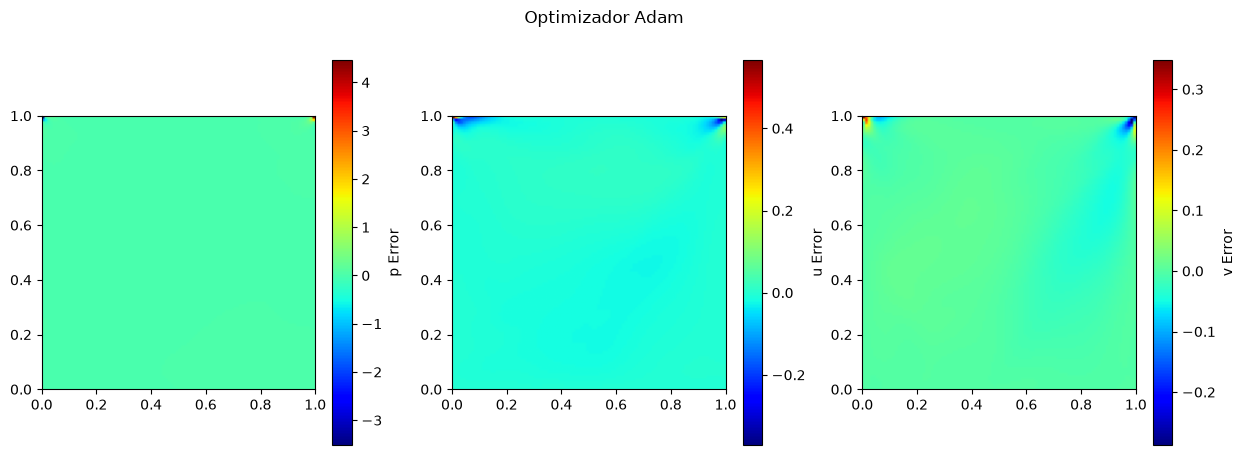

In [61]:
error_abs = y_data_all.numpy() - y_pred
error_abs_df = pd.DataFrame(np.hstack((X_data_all, error_abs)), columns=['x', 'y', 'p_err', 'u_err', 'v_err'])
print(error_abs_df.head())

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
[ax.set_xlim(0,1) for ax in axs]
[ax.set_ylim(0,1) for ax in axs]
[
    # sns.heatmap(
    #     data = error_abs_df,
    #     annot = False,
    #     # cmap
    # )
    # ax.imshow(
    #     error_abs_df.pivot_table(index='y', columns='x', values=col).values,
    #     extent=(0, 1, 0, 1),
    #     cmap='viridis'
    # )
    ax.imshow(
        griddata(
            # np.column_stack((pred_df['x'], pred_df['y'])),
            X_data_all.numpy(),
            error_abs_df[col],
            np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100)),
            method='cubic'
        ),
        # pred_df.pivot_table(index='y', columns='x', values=col).values,
        origin='lower',
        extent=(0, 1, 0, 1),
        cmap='jet'
    )
    # for ax, col in zip(axs, ['p', 'u', 'v'])
    for ax, col in zip(axs, ['p_err', 'u_err', 'v_err'])
]
fig.colorbar(axs[0].images[0], ax=axs[0], label='p Error')
fig.colorbar(axs[1].images[0], ax=axs[1], label='u Error')
fig.colorbar(axs[2].images[0], ax=axs[2], label='v Error')
fig.suptitle("Optimizador Adam")

Text(0.5, 0.98, 'Optimizador Adam')

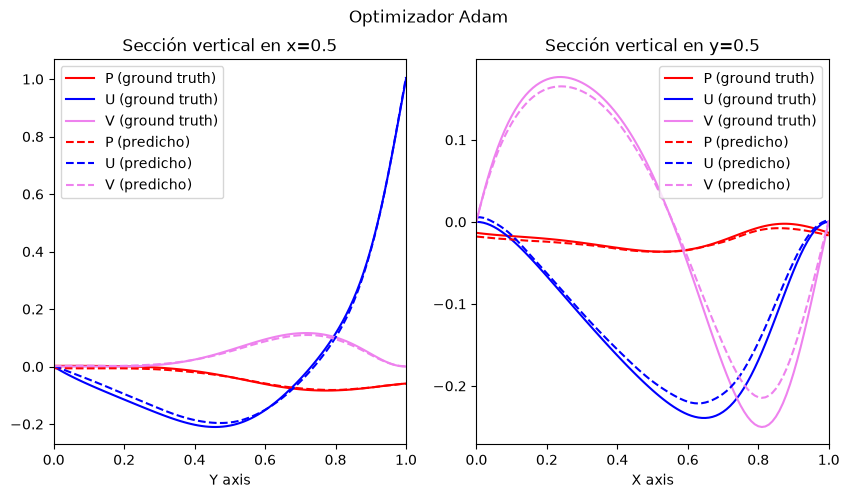

In [62]:
X_x05 = X_data_all[X_data_all[:, 0] == 0.5]
X_y05 = X_data_all[X_data_all[:, 1] == 0.5]
y_data_x05 = y_data_all[X_data_all[:, 0] == 0.5]
y_pred_x05 = y_pred[X_data_all[:, 0] == 0.5]
y_data_y05 = y_data_all[X_data_all[:, 1] == 0.5]
y_pred_y05 = y_pred[X_data_all[:, 1] == 0.5]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].plot(X_x05[:, 1].numpy(), y_data_x05[:, 0].numpy(), label='P (ground truth)', color='red'   )
axs[0].plot(X_x05[:, 1].numpy(), y_data_x05[:, 1].numpy(), label='U (ground truth)', color='blue'  )
axs[0].plot(X_x05[:, 1].numpy(), y_data_x05[:, 2].numpy(), label='V (ground truth)', color='violet')
axs[0].plot(X_x05[:, 1].numpy(), y_pred_x05[:, 0], label='P (predicho)', linestyle='dashed', color='red'   )
axs[0].plot(X_x05[:, 1].numpy(), y_pred_x05[:, 1], label='U (predicho)', linestyle='dashed', color='blue'  )
axs[0].plot(X_x05[:, 1].numpy(), y_pred_x05[:, 2], label='V (predicho)', linestyle='dashed', color='violet')
axs[0].legend()
axs[0].set_title('Sección vertical en x=0.5')
axs[0].set_xlabel('Y axis')

axs[1].plot(X_y05[:, 0].numpy(), y_data_y05[:, 0].numpy(), label='P (ground truth)', color='red'   )
axs[1].plot(X_y05[:, 0].numpy(), y_data_y05[:, 1].numpy(), label='U (ground truth)', color='blue'  )
axs[1].plot(X_y05[:, 0].numpy(), y_data_y05[:, 2].numpy(), label='V (ground truth)', color='violet')
axs[1].plot(X_y05[:, 0].numpy(), y_pred_y05[:, 0], label='P (predicho)', linestyle='dashed', color='red'   )
axs[1].plot(X_y05[:, 0].numpy(), y_pred_y05[:, 1], label='U (predicho)', linestyle='dashed', color='blue'  )
axs[1].plot(X_y05[:, 0].numpy(), y_pred_y05[:, 2], label='V (predicho)', linestyle='dashed', color='violet')
axs[1].legend()
axs[1].set_title('Sección vertical en y=0.5')
axs[1].set_xlabel('X axis')

[ax.set_xlim(0,1) for ax in axs]
fig.suptitle("Optimizador Adam")